# Imports

In [1]:
import matplotlib.pyplot as plt
#%matplotlib qt
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import os

from moabb.datasets import BNCI2015_013
import mne
from mne.preprocessing import ICA

from pyriemann.estimation import XdawnCovariances
from pyriemann.tangentspace import TangentSpace

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, validation_curve, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, make_scorer,confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report, roc_curve, auc, precision_score, recall_score

# Dataset NER

[Dataset link](https://www.kaggle.com/competitions/inria-bci-challenge/data)

In [ ]:
# Loading paths and labels
data_dir = "C:/Users/oskik/_0_My_folder/Magisterka/kod_classification_model/bci_train"
labels_path = 'TrainLabels.csv'

labels_df = pd.read_csv(labels_path)
labels_dict = dict(zip(labels_df['IdFeedBack'], labels_df['Prediction']))

event_dict = {'Target': 0, "NonTarget": 1}
X_dict = {}
y_dict = {}    
results = {
    'within': [],
    'pooled': [],
    'cross': []
}

all_data_files = glob.glob(os.path.join(data_dir, 'Data_S*_Sess*.csv'))
subjects = sorted(list(set([os.path.basename(f).split('_')[1] for f in all_data_files])))

print(f"Found {len(subjects)} subjects in the folder: {subjects}\n")

Found 16 subjects in the folder: ['S02', 'S06', 'S07', 'S11', 'S12', 'S13', 'S14', 'S16', 'S17', 'S18', 'S20', 'S21', 'S22', 'S23', 'S24', 'S26']



In [3]:
for subject_id in subjects:
    print(f"Processing subject: {subject_id}")
    X_sub_list = []
    y_sub_list = []
    
    # Finding all session files for the current subject 
    data_files = sorted(glob.glob(os.path.join(data_dir, f'Data_{subject_id}_Sess*.csv')))
    
    for data_file in data_files:
        # Getting the session number from the filename
        session_id = os.path.basename(data_file).replace('.csv', '').split('_')[2] 
        
        # Getting the data into a DataFrame
        df = pd.read_csv(data_file)
        ch_names = list(df.columns)[1:]
        
        # Naming the channels according to MNE conventions
        ch_types = []
        for ch in ch_names:
            if ch == 'FeedBackEvent':
                ch_types.append('stim')
            elif ch == 'EOG':
                ch_types.append('eog')
            else:
                ch_types.append('eeg')
                
        # Creating MNE Info object
        info = mne.create_info(ch_names=ch_names, sfreq=200.0, ch_types=ch_types)
        
        # Transposing the data to match MNE's expected shape (n_channels, n_times)
        data_matrix = df[ch_names].values.T 
        
        # Creating MNE Raw object
        raw_run = mne.io.RawArray(data_matrix, info, verbose=False)
        
        # FIR (Bandpass) for 1-10 Hz
        raw_run.filter(l_freq=1.0, h_freq=10.0, picks='eeg', fir_design='firwin', verbose=False)

        # CAR - Common Average Reference
        raw_run.set_eeg_reference(ref_channels='average', ch_type='eeg', verbose=False)
        
        # Detecting events based on 'FeedBackEvent' channel
        raw_events = mne.find_events(raw_run, stim_channel='FeedBackEvent', verbose=False)
        
        mne_events = []
        
        # Creating labels for each event
        for i, event in enumerate(raw_events):
            fb_id = f"{subject_id}_{session_id}_FB{i+1:03d}"
            
            if fb_id in labels_dict:
                label = int(labels_dict[fb_id]) # 0 (bad) or 1 (good)
                mne_events.append([event[0], 0, label])
                
        if not mne_events:
            continue
            
        mne_events = np.array(mne_events)
        
        # Creating epochs around the events
        epochs = mne.Epochs(
            raw=raw_run,
            events=mne_events,
            event_id=[0, 1], # 0 = Bad/Target, 1 = Good
            tmin=-0.2,
            tmax=0.8,
            baseline=(-0.2, 0),
            decim=4,         # Downsampling from 200 Hz to 50 Hz (cause 64 Hz wouldnt work with 200 Hz)
            preload=True,
            picks='eeg',
            verbose=False
        )

        X_sub_list.append(epochs.get_data(copy=True))
        y_sub_list.append(epochs.events[:, -1])

    # Creating one big array for the subject by concatenating all sessions
    if X_sub_list:
        X_dict[subject_id] = np.concatenate(X_sub_list, axis=0)
        y_dict[subject_id] = np.concatenate(y_sub_list, axis=0)

Processing subject: S02
Processing subject: S06
Processing subject: S07
Processing subject: S11
Processing subject: S12
Processing subject: S13
Processing subject: S14
Processing subject: S16
Processing subject: S17
Processing subject: S18
Processing subject: S20
Processing subject: S21
Processing subject: S22
Processing subject: S23
Processing subject: S24
Processing subject: S26


In [4]:
# Szybkie sprawdzenie wymiarów dla pierwszego pacjenta
first_sub = list(X_dict.keys())[0]
n_epochs, n_channels, n_times = X_dict[first_sub].shape
print(f"Przykładowe dane dla {first_sub}:")
print(f" -> Liczba epok:   {n_epochs}")
print(f" -> Liczba kanał.: {n_channels} (Tylko EEG)")
print(f" -> Próbki czas.:  {n_times} (po downsamplingu)")

# Szybkie sprawdzenie rozkładu klas dla tego pacjenta
unique, counts = np.unique(y_dict[first_sub], return_counts=True)
class_distribution = dict(zip(unique, counts))
print(f" -> Rozkład klas:  {class_distribution} (0=Bad, 1=Good)")

Przykładowe dane dla S02:
 -> Liczba epok:   280
 -> Liczba kanał.: 56 (Tylko EEG)
 -> Próbki czas.:  51 (po downsamplingu)
 -> Rozkład klas:  {np.int64(0): np.int64(110), np.int64(1): np.int64(170)} (0=Bad, 1=Good)


# Pipeline
We will use Xdawn covariances, which calculate extract the noise from the channels (Xdawn) and calulcate the covariances on clean channels.
Then we move our data to Riemannian tangent space in which a Linear SVM can perform classification.

In [ ]:
pipe = Pipeline([
    ('xdawn', XdawnCovariances(nfilter=4, estimator='oas', xdawn_estimator='oas')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', SVC(
        class_weight='balanced',
        kernel='linear',
        C=0.1,
        random_state=42
    ))
])

# Model

### Within subject

In [ ]:
for subject_id in subjects:    
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]

    split_idx = int(len(X_sub) * 0.7)
    
    # Split the data chronologically (NO SHUFFLING)
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    

    # Checking if every class is present in the test set
    unique_classes, counts = np.unique(y_test, return_counts=True)
    if 0 not in unique_classes:
        print(f"WARNING: Subject {subject_id} does not have the Target class in the test set!")

    # Train the model on the past (Calibration)
    pipe.fit(X_train, y_train)
    
    # Test the model on the future (Active Steering)
    y_pred = pipe.predict(X_test)
    for ytrue, ypred in zip(y_test, y_pred):
        results['within'].append({
            'subject': subject_id,
            'y_true': ytrue,
            'y_pred': ypred
        })

#### ROC and AUC

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, subject_id in enumerate(subjects):
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]

    split_idx = int(len(X_sub) * 0.70)
    
    # Podział chronologiczny
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    
    # Trenowanie
    pipe.fit(X_train, y_train)
    
    # Zamiast twardego .predict(), pobieramy ciągłe wartości zaufania modelu
    y_scores = pipe.decision_function(X_test)
    
    # Wyliczanie FPR, TPR oraz optymalnych progów. 
    # Pamiętamy o pos_label=1 (Klasa BŁĄD)
    fpr, tpr, thresholds = roc_curve(y_test, y_scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    # Wizualizacja
    ax = axes[i]
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowe zgadywanie')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (Fałszywe Alarmy)')
    ax.set_ylabel('True Positive Rate (Wykryte Błędy)')
    ax.set_title(f'Pacjent S{subject_id:02d}', fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Krzywe ROC dla detekcji sygnału ErrP (Klasa BŁĄD)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Cross-subject

In [82]:
for test_subject in subjects:
    X_train = np.concatenate([X_dict[subject_id] for s in subjects if s != test_subject], axis=0)
    y_train = np.concatenate([y_dict[subject_id] for s in subjects if s != test_subject], axis=0)
    X_test = X_dict[test_subject]
    
    pipe.fit(X_train, y_train)
    y_pred_cross = pipe.predict(X_test)
    for ytrue, ypred in zip(y_dict[test_subject], y_pred_cross):
        results['cross'].append({
            'subject': test_subject,
            'y_true': ytrue,
            'y_pred': ypred
        })

KeyboardInterrupt: 

### Save to CSV

In [ ]:
pd.DataFrame(results['within']).to_csv("riemann_ner_within.csv", index=False)
#pd.DataFrame(results['cross']).to_csv("riemann_ner_cross.csv", index=False)

# Wizki

In [ ]:
df_within = pd.read_csv("riemann_ner_within.csv")
#df_cross = pd.read_csv("riemann_ner_cross.csv")
results_table = []

### Metrics function

In [54]:
def calculate_metrics(df, experiment_name):

    for subject, group in df.groupby('subject'):
        y_true = group['y_true']
        y_pred = group['y_pred']
        
        acc = balanced_accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, pos_label=0)
        precision = precision_score(y_true, y_pred, pos_label=0)
        recall = recall_score(y_true, y_pred, pos_label=0)
        
        results_table.append({
            'Experiment': experiment_name,
            'Patient': f"{subject}",
            'Balanced Accuracy (%)': round(acc, 2),
            'F1-Score (ErrP)': round(f1, 3),
            'Precision (ErrP)': round(precision, 3),
            'Recall (ErrP)': round(recall, 3)
        })

In [55]:
calculate_metrics(df_within, 'Within-Subject')
#calculate_metrics(df_cross, 'Cross-Subject')
df_results = pd.DataFrame(results_table)

In [ ]:
print("--- RESULTS TABLE ---")
print(df_results.to_string(index=False))

--- TABELA ZBIORCZA WYNIKÓW ---
    Experiment Patient  Balanced Accuracy (%)  F1-Score (ErrP)  Precision (ErrP)  Recall (ErrP)
Within-Subject       1                  77.47            0.882             0.911          0.855
Within-Subject       2                  88.02            0.949             0.965          0.933
Within-Subject       3                  79.70            0.923             0.930          0.917
Within-Subject       4                  88.57            0.972             0.945          1.000
Within-Subject       5                  82.59            0.905             0.932          0.879
Within-Subject       6                  51.92            0.751             0.815          0.696


In [ ]:
pd.DataFrame(df_results.to_csv("riemann_ner_results.csv", index=False))

""


In [ ]:
def plot_confusion_matrices(df, experiment_name, filename):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
    axes = axes.flatten()
    
    subjects_list = sorted(df['subject'].unique())
    
    for i, sub_id in enumerate(subjects_list):
        ax = axes[i]
        
        sub_data = df[df['subject'] == sub_id]
        y_true = sub_data['y_true']
        y_pred = sub_data['y_pred']
        
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Correct', 'ERROR'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        
        ax.set_title(f"Patient {sub_id}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Class')
        ax.set_ylabel('True Class')
    
    plt.suptitle(f"Confusion Matrices - {experiment_name}", fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

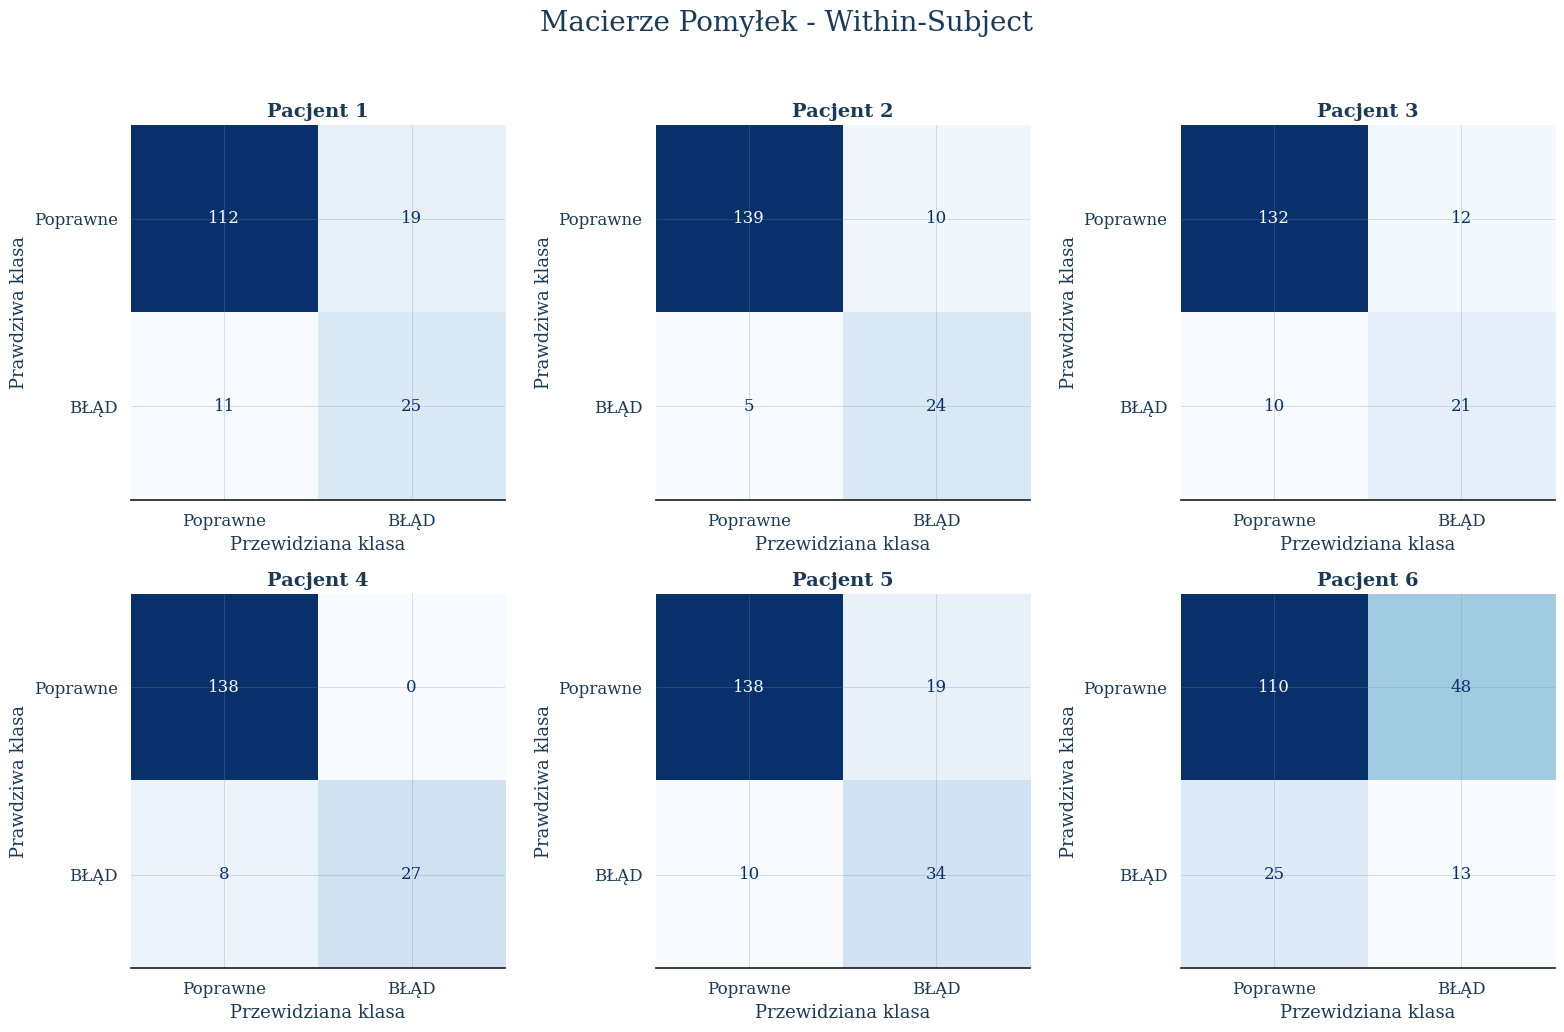

In [59]:
plot_confusion_matrices(df_within, 'Within-Subject', 'Riemann_Within_Subject.png')
#plot_confusion_matrices(df_cross, 'Cross-Subject', 'Riemann_Cross_Subject.png')

In [ ]:
# Create subplots for each metric
df = pd.read_csv("riemann_ner_results.csv")
metrics = df.columns[2:]
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

target_bar_index = 11
chosen_hex_color = "#e66101"

for i, metric in enumerate(metrics):
    sns.barplot(data=df, x='Patient', y=metric, hue='Experiment', ax=axes[i], palette=['#b2abd2', '#fdb863'])

    mean_within = df[df['Experiment'] == 'Within-Subject'][metric].mean()
    mean_cross = df[df['Experiment'] == 'Cross-Subject'][metric].mean()
    
    # Plot horizontal mean lines
    axes[i].axhline(mean_within, color='#b2abd2', linestyle='--', linewidth=0.8, zorder=0)
    axes[i].axhline(mean_cross, color='#fdb863', linestyle='--', linewidth=0.8, zorder=0)

    if metric == 'Recall (ErrP)':
        patches = axes[i].patches
        if len(patches) > target_bar_index:
            patches[target_bar_index].set_facecolor(chosen_hex_color)

    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xlabel("Patient", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].tick_params(axis='both', which='major', labelsize=7)
    
    if i == 0:
        axes[i].legend(title='Experiment', fontsize=6, title_fontsize=8, loc='lower left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout(pad=0.5, w_pad=2.0, h_pad=2.0)
plt.savefig("riemann_ner_results.svg", dpi=300)

# MISC

## Chat

### Badanie ilościowe

In [ ]:
for subject_id in subjects:
    # Extract the shape of the data array
    total_trials, channels, time_samples = X_dict[subject_id].shape
    
    # Calculate how many trials go into the 70% split
    split_idx = int(total_trials * 0.70)
    test_trials = total_trials - split_idx
    
    print(f"--- Pacjent {subject_id} ---")
    print(f"Całkowita liczba prób (Epochs): {total_trials}")
    print(f"Liczba kanałów (Channels):      {channels}")
    print(f"Próbki czasowe (Time samples):  {time_samples}")
    print(f"  -> Trening (Kalibracja):      {split_idx} prób")
    print(f"  -> Test (Sterowanie):         {test_trials} prób\n")

--- Pacjent 1 ---
Całkowita liczba prób (Epochs): 1044
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      730 prób
  -> Test (Sterowanie):         314 prób

--- Pacjent 2 ---
Całkowita liczba prób (Epochs): 1080
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      756 prób
  -> Test (Sterowanie):         324 prób

--- Pacjent 3 ---
Całkowita liczba prób (Epochs): 1036
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      725 prób
  -> Test (Sterowanie):         311 prób

--- Pacjent 4 ---
Całkowita liczba prób (Epochs): 1052
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      736 prób
  -> Test (Sterowanie):         316 prób

--- Pacjent 5 ---
Całkowita liczba prób (Epochs): 1123
Liczba kanałów (Channels):      64
Próbki czasowe (Time samples):  129
  -> Trening (Kalibracja):      786 pr

### GridSearch parametrów

In [ ]:
# 1. Definicja potoku (bez twardego kodowania nfilter i C, zostaną one nadpisane)
pipe = Pipeline([
    ('xdawn', XdawnCovariances(estimator='oas', xdawn_estimator='oas')), 
    ('ts', TangentSpace(metric='riemann')),
    ('clf', SVC(class_weight='balanced', kernel='linear', random_state=42))
])

# 2. Przestrzeń poszukiwań (Grid)
param_grid = {
    # Liczba filtrów przestrzennych. 
    # 2-3 to standard, 4-6 pozwala wyciągnąć więcej detali, ale ryzykuje przeuczeniem.
    'xdawn__nfilter': [2, 3, 4, 5, 6, 7],
    
    # Parametr regularyzacji SVM. 
    # Mniejsze wartości (0.01, 0.1) silniej ignorują szum. Większe (0.5, 1.0) tworzą twardszą granicę.
    'clf__C': [0.001, 0.01, 0.1, 1.0, 10.0]
}

# 3. Konfiguracja GridSearchCV
# Używamy StratifiedKFold z 3 podziałami, aby zachować proporcje klas (błąd vs poprawne) w każdym foldzie.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gsearch = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1',           # Optymalizujemy stricte pod kątem F1-Score
    cv=cv_strategy,
    n_jobs=-1,              # Użycie wszystkich rdzeni procesora (znaczne przyspieszenie)
    verbose=1               # Wyświetla postęp w konsoli
)

# Słownik do przechowywania najlepszych modeli dla każdego pacjenta
best_models = {}
grid_results_list = []

print("Rozpoczynam Grid Search dla optymalnego okna czasowego...\n")

for subject_id in subjects: # Zakładamy, że X_dict i y_dict mają już dane z okna np. [-0.2, 1.0]
    print(f"--- Optymalizacja pacjenta: S{subject_id:02d} ---")
    
    X_sub = X_dict[subject_id]
    y_sub = y_dict[subject_id]
    
    # Chronologiczny podział na zbiór kalibracyjny (treningowy) i testowy (aktywna jazda)
    split_idx = int(len(X_sub) * 0.70)
    X_train, y_train = X_sub[:split_idx], y_sub[:split_idx]
    X_test, y_test = X_sub[split_idx:], y_sub[split_idx:]
    
    # Weryfikacja, czy zbiór treningowy posiada obie klasy
    if len(np.unique(y_train)) < 2:
        print(f"OSTRZEŻENIE: Brak wystarczającej liczby klas w zbiorze treningowym dla S{subject_id:02d}. Pomijam.")
        continue

    # Uruchomienie przeszukiwania siatki TYLKO na zbiorze treningowym
    gsearch.fit(X_train, y_train)
    
    best_pipe = gsearch.best_estimator_
    best_models[subject_id] = best_pipe
    
    print(f"Najlepsze parametry: {gsearch.best_params_}")
    print(f"Najlepszy F1-Score (Cross-Validation): {gsearch.best_score_:.3f}")
    
    # 4. Ostateczna ewaluacja na niewidzianym zbiorze testowym
    y_pred = best_pipe.predict(X_test)
    
    print("\nRaport na ukrytym zbiorze testowym (Przyszłość):")
    print(classification_report(y_test, y_pred, target_names=['Poprawne (0)', 'BŁĄD (1)']))
    print("=" * 60 + "\n")
    
    grid_results_list.append({
        'Pacjent': f"S{subject_id:02d}",
        'Najlepszy nfilter': gsearch.best_params_['xdawn__nfilter'],
        'Najlepsze C': gsearch.best_params_['clf__C'],
        'F1_CV (Trening)': round(gsearch.best_score_, 3)
    })

# Zapisanie ostatecznych hiperparametrów do tabeli
df_params = pd.DataFrame(grid_results_list)
print("Zestawienie optymalnych hiperparametrów dla każdego z pacjentów:")
print(df_params.to_string(index=False))
nazwa_pliku_csv = 'grid_search_params.csv'
df_params.to_csv(nazwa_pliku_csv, index=False)
print(f"\nWyniki zapisano pomyślnie do pliku: {nazwa_pliku_csv}")

Rozpoczynam Grid Search dla optymalnego okna czasowego...

--- Optymalizacja pacjenta: S01 ---
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najlepsze parametry: {'clf__C': 0.01, 'xdawn__nfilter': 6}
Najlepszy F1-Score (Cross-Validation): 0.795

Raport na ukrytym zbiorze testowym (Przyszłość):
              precision    recall  f1-score   support

Poprawne (0)       0.94      0.92      0.93       238
    BŁĄD (1)       0.77      0.80      0.79        76

    accuracy                           0.89       314
   macro avg       0.85      0.86      0.86       314
weighted avg       0.90      0.89      0.90       314


--- Optymalizacja pacjenta: S02 ---
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najlepsze parametry: {'clf__C': 0.01, 'xdawn__nfilter': 5}
Najlepszy F1-Score (Cross-Validation): 0.856

Raport na ukrytym zbiorze testowym (Przyszłość):
              precision    recall  f1-score   support

Poprawne (0)       0.95      0.97      0.96       252
  